# Feature Engineering - Chicago Rideshare Demand

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import warnings
import requests
import h3
import json
from itertools import product
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
h3_feat = pd.read_parquet('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed/chirde.h3_features.parquet')
h3_feat.head()

,h3_index,trip_count,avg_fare,avg_duration_min,avg_distance,tip_rate,latitude,longitude
0,8826641915fffff,1879,10.87,10.5,4.34,13.8,41.661930,-87.543619
1,882664191dfffff,221,11.44,11.2,4.45,5.9,41.668364,-87.536948
2,8826641937fffff,74,12.03,11.1,4.77,17.6,41.650113,-87.568330
3,8826641943fffff,4,10.00,10.6,3.52,25.0,41.689771,-87.539691
4,8826641949fffff,57,11.89,10.0,3.17,12.3,41.703694,-87.537725


In [ ]:
h3_rides = pd.read_parquet('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed/chirde.h3_rides.parquet')
h3_rides.head()

,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,pickup_community_area,fare,tip,additional_charges,trip_total,shared_trip_authorized,...,latitude,longitude,hour,day_of_week,day_name,date,week,is_weekend,week_label,h3_index
0,2024-12-31 23:45:00,2024-12-31 23:45:00,300.0,0.9,32,2.5,3.0,2.56,8.06,False,...,41.870605,-87.622169,23,1,Tuesday,2024-12-31,1,False,Week1,882664c1abfffff
1,2024-12-31 23:45:00,2025-01-01 00:00:00,860.0,4.6,6,15.0,0.0,4.50,19.50,False,...,41.949062,-87.661644,23,1,Tuesday,2024-12-31,1,False,Week1,882664c161fffff
2,2024-12-31 23:45:00,2025-01-01 00:00:00,275.0,1.1,6,7.5,0.0,2.89,10.39,False,...,41.944225,-87.655998,23,1,Tuesday,2024-12-31,1,False,Week1,882664c163fffff
3,2024-12-31 23:45:00,2024-12-31 23:45:00,588.0,0.6,8,5.0,0.0,2.63,7.63,False,...,41.890923,-87.618866,23,1,Tuesday,2024-12-31,1,False,Week1,882664c1e3fffff
4,2024-12-31 23:45:00,2024-12-31 23:45:00,443.0,4.2,28,10.0,0.0,3.79,13.79,False,...,41.885281,-87.657234,23,1,Tuesday,2024-12-31,1,False,Week1,882664cad7fffff


#### Hourly Demand Grid

##### 1. Hour column for aggregation

In [ ]:
h3_rides['hour_bucket'] = h3_rides['trip_start_timestamp'].dt.floor('h')
print(f"Hours in range: {(h3_rides['hour_bucket'].max() - h3_rides['hour_bucket'].min()).total_seconds() / 3600:.0f}")

Hours in range: 743


##### 2. Spatial granularity
`CITYWIDE: total trips per hour.
PER H3 CELL: trips per hour per H3 cell`

In [ ]:
# Citywide aggregation
citywide_hourly = h3_rides.groupby('hour_bucket').agg(
    trip_count = ('trip_start_timestamp', 'size'),
    avg_fare = ('fare', 'mean'),
    avg_duration_sec = ('trip_seconds', 'mean'),
    avg_distance = ('trip_miles', 'mean'),
    shared_pct = ('shared_trip_authorized', 'mean'),
    avg_tip = ('tip', 'mean'),
    unique_areas = ('pickup_community_area', 'nunique'),
    unique_h3_cells = ('h3_index', 'nunique')
).reset_index()

print(citywide_hourly.head())

          hour_bucket  trip_count   avg_fare  avg_duration_sec  avg_distance  \
0 2024-12-01 00:00:00        8370   9.428017        548.647644      2.935735   
1 2024-12-01 01:00:00        6510   9.882873        542.183899      3.069201   
2 2024-12-01 02:00:00        4982  11.844641        551.633057      3.171457   
3 2024-12-01 03:00:00        3170  10.682965        551.315125      3.331767   
4 2024-12-01 04:00:00        2208  10.527627        563.942932      3.561821   

   shared_pct   avg_tip  unique_areas  unique_h3_cells  
0    0.035245  0.616010            78              337  
1    0.035330  0.588326            78              257  
2    0.036933  0.596146            78              219  
3    0.046372  0.584543            78              189  
4    0.054801  0.596467            74              156  


In [ ]:
# H3 cell aggregation
min_total_trips = 50 # Atleast 50 trips over the whole month
active_cells = h3_feat[h3_feat['trip_count'] >= min_total_trips]['h3_index'].tolist()

In [ ]:
h3_rides_active = h3_rides[h3_rides['h3_index'].isin(active_cells)].copy()

h3_hourly = (h3_rides_active.groupby(['hour_bucket', 'h3_index']).agg(
    trip_count = ('trip_start_timestamp', 'size'),
    avg_fare = ('fare', 'mean'),
    avg_duration_sec = ('trip_seconds', 'mean'),
    avg_distance = ('trip_miles', 'mean'),
    shared_pct = ('shared_trip_authorized', 'mean')
).reset_index()
)

`If a cell has no trips at 3 AM on Dec 15, that row doesn't exist. But we should consider 'zero demand'.`

In [ ]:
all_hours = pd.date_range(
    start = citywide_hourly['hour_bucket'].min(),
    end = citywide_hourly['hour_bucket'].max(),
    freq = 'h'
)

# full grid: every hour x every active cell
full_grid = pd.DataFrame(
    list(product(all_hours, active_cells)),
    columns = ['hour_bucket', 'h3_index']
)

print(len(full_grid))

h3_hourly_comp = full_grid.merge(h3_hourly, on = ['hour_bucket', 'h3_index'], how = 'left')
h3_hourly_comp['trip_count'] = h3_hourly_comp['trip_count'].fillna(0).astype(int)

for col in ['avg_fare', 'avg_duration_sec', 'avg_distance', 'shared_pct']:
    h3_hourly_comp[col] = h3_hourly_comp[col].fillna(0)


zero_hours = (h3_hourly_comp['trip_count'] == 0).sum()
print(f"Zero demand hours: {zero_hours:,} ({zero_hours/len(h3_hourly_comp)*100:.1f}%)")

403248
Zero demand hours: 172,731 (42.8%)


In [ ]:
cell_info = h3_hourly_comp.groupby('h3_index').agg(Avg_trip_count = ('trip_count', 'mean'))
print(cell_info)

                 Avg_trip_count
h3_index                       
8826641915fffff        2.525538
882664191dfffff        0.297043
8826641937fffff        0.099462
8826641949fffff        0.076613
8826641961fffff        7.662634
...                         ...
88275936b7fffff        0.072581
88275936bbfffff        0.900538
88275936cbfffff        0.107527
88275936d3fffff        1.518817
88275936d5fffff        7.106183

[542 rows x 1 columns]


##### 3. Calender / Temporal Features

In [ ]:
def add_calender_features(df, time_col = 'hour_bucket'):
    d = df.copy()

    d['hour'] = d[time_col].dt.hour
    d['day_of_week'] = d[time_col].dt.dayofweek
    d['day_of_month'] = d[time_col].dt.day
    d['week_of_year'] = d[time_col].dt.isocalendar().week.astype(int)
    d['is_weekend'] = d[time_col].isin([5, 6])

    d['day_name'] = d[time_col].dt.day_name()

    def get_period(hour):
        if hour < 6:
            return 'late_night'
        elif hour < 10:
            return 'morning_rush'
        elif hour < 16:
            return 'midday'
        elif hour < 20:
            return 'evening_rush'
        elif hour < 23:
            return 'evening'
        else:
            return 'late_night'

    
    d['period_of_day'] = d['hour'].apply(get_period)

    # Rush hour (Morning 7-9AM, Evening 4-7PM (week days))
    d['is_rush_hour'] = (d['is_weekend'] == False & (d['hour'].between(7, 9)) | d['hour'].between(16, 19))

    # Holidays
    holidays = {
        '2024-12-24': 'christmas_eve',
        '2024-12-25': 'christmas_day',
        '2024-12-26': 'day_after_christmas',
        '2024-12-31': 'new_years_eve',
        '2025-01-01': 'new_years_day',
    }
    holiday_dates = [pd.Timestamp(d) for d in holidays.keys()]

    d['date'] = d[time_col].dt.date
    d['is_holiday'] = d['date'].astype(str).isin(holidays.keys())

    d['holiday_name'] = d['date'].astype(str).map(holidays).fillna('none')

    def days_to_nearest_holiday(timestamp):
        if not holiday_dates:
            return 99

        diffs = [(timestamp - h).days for h in holiday_dates]
        return min(diffs, key = abs)

    
    d['holiday_proximity'] = d[time_col].apply(
        lambda x: days_to_nearest_holiday(pd.Timestamp(x.date()))
    )

    # New Year's Eve Handling
    d['is_nye_evening'] = (
        (d['date'].astype(str) == '2024-12-31') & (d['hour'] >= 20)
    ) | ((d['date'].astype(str) == '2025-01-01') & (d['hour'] <= 4))


    # Cyclical encodings
    # Hour 23 and hour 0 are adjacent, but numerically far apart (23 vs 0)
    # Sin/cos encoding makes them neighbors in feature space.

    d['hour_sin'] = np.sin(2 * np.pi * d['hour'] / 24)
    d['hour_cos'] = np.cos(2 * np.pi * d['hour'] / 24)

    d['dow_sin'] = np.sin(2 * np.pi * d['day_of_week'] / 7)
    d['dow_cos'] = np.cos(2 * np.pi * d['day_of_week'] / 7)
    
    # Day of month cyclical (captures monthly patterns)
    d['dom_sin'] = np.sin(2 * np.pi * d['day_of_month'] / 31)
    d['dom_cos'] = np.cos(2 * np.pi * d['day_of_month'] / 31)

    return d


citywide_hourly = add_calender_features(citywide_hourly)
print(citywide_hourly.shape[1])

h3_hourly_comp = add_calender_features(h3_hourly_comp)
print(h3_hourly_comp.shape[1])

28
26


In [ ]:
citywide_hourly.head()

,hour_bucket,trip_count,avg_fare,avg_duration_sec,avg_distance,shared_pct,avg_tip,unique_areas,unique_h3_cells,hour,...,is_holiday,holiday_name,holiday_proximity,is_nye_evening,hour_sin,hour_cos,dow_sin,dow_cos,dom_sin,dom_cos
0,2024-12-01 00:00:00,8370,9.428017,548.647644,2.935735,0.035245,0.616010,78,337,0,...,False,none,-23,False,0.000000,1.000000,-0.781831,0.62349,0.201299,0.97953
1,2024-12-01 01:00:00,6510,9.882873,542.183899,3.069201,0.035330,0.588326,78,257,1,...,False,none,-23,False,0.258819,0.965926,-0.781831,0.62349,0.201299,0.97953
2,2024-12-01 02:00:00,4982,11.844641,551.633057,3.171457,0.036933,0.596146,78,219,2,...,False,none,-23,False,0.500000,0.866025,-0.781831,0.62349,0.201299,0.97953
3,2024-12-01 03:00:00,3170,10.682965,551.315125,3.331767,0.046372,0.584543,78,189,3,...,False,none,-23,False,0.707107,0.707107,-0.781831,0.62349,0.201299,0.97953
4,2024-12-01 04:00:00,2208,10.527627,563.942932,3.561821,0.054801,0.596467,74,156,4,...,False,none,-23,False,0.866025,0.500000,-0.781831,0.62349,0.201299,0.97953


In [ ]:
h3_hourly_comp.head()

,hour_bucket,h3_index,trip_count,avg_fare,avg_duration_sec,avg_distance,shared_pct,hour,day_of_week,day_of_month,...,is_holiday,holiday_name,holiday_proximity,is_nye_evening,hour_sin,hour_cos,dow_sin,dow_cos,dom_sin,dom_cos
0,2024-12-01,8826641915fffff,3,5.000000,628.666687,4.033333,0.333333,0,6,1,...,False,none,-23,False,0.0,1.0,-0.781831,0.62349,0.201299,0.97953
1,2024-12-01,882664191dfffff,0,0.000000,0.000000,0.000000,0.000000,0,6,1,...,False,none,-23,False,0.0,1.0,-0.781831,0.62349,0.201299,0.97953
2,2024-12-01,8826641937fffff,0,0.000000,0.000000,0.000000,0.000000,0,6,1,...,False,none,-23,False,0.0,1.0,-0.781831,0.62349,0.201299,0.97953
3,2024-12-01,8826641949fffff,0,0.000000,0.000000,0.000000,0.000000,0,6,1,...,False,none,-23,False,0.0,1.0,-0.781831,0.62349,0.201299,0.97953
4,2024-12-01,8826641961fffff,7,8.214286,632.142883,4.885715,0.285714,0,6,1,...,False,none,-23,False,0.0,1.0,-0.781831,0.62349,0.201299,0.97953


##### 4. Lag features

In [ ]:
def add_lag_features_citywide(df, target_col = 'trip_count'):
    d = df.sort_values('hour_bucket').copy()

    # Short term lags
    for lag in [1, 2, 3]:
        d[f'lag_{lag}h'] = d[target_col].shift(lag)

    
    # Same hour yesterday
    d['lag_24h'] = d[target_col].shift(24)

    # Same hour, 2 days ago
    d['lag_48h'] = d[target_col].shift(48)

    # Same hour last week
    d['lag_168h'] = d[target_col].shift(168)

    # Demand changes
    d['demand_change_1h'] = d[target_col] - d[f'lag_1h']
    d['demand_change_24h'] = d[target_col] - d['lag_24h']

    d['demand_pct_change_1h'] = d['demand_change_1h'] / d[f'lag_1h'].replace(0, np.nan)

    return d


def add_lag_features_h3(df, target_col = 'trip_count'):
    d = df.sort_values(['h3_index', 'hour_bucket']).copy()

    for lag in [1, 2, 3]:
        d[f'lag_{lag}h'] = d.groupby('h3_index')[target_col].shift(lag)

    d['lag_24h'] = d.groupby('h3_index')[target_col].shift(24)
    d['lag_48h'] = d.groupby('h3_index')[target_col].shift(48)
    d['lag_168h'] = d.groupby('h3_index')[target_col].shift(168)

    d['demand_change_1h'] = d[target_col] - d['lag_1h']
    d['demand_change_24h'] = d[target_col] - d['lag_24h']

    return d


citywide_hourly = add_lag_features_citywide(citywide_hourly)
lag_cols = [c for c in citywide_hourly.columns if 'lag_' in c or 'demand_change' in c]
print('Lag Features citywide: {}'.format(lag_cols))

h3_hourly_comp = add_lag_features_h3(h3_hourly_comp)
lag_cols = [c for c in citywide_hourly.columns if 'lag_' in c or 'demand_change' in c]
print('Lag Features h3: {}'.format(lag_cols))

Lag Features citywide: ['lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_48h', 'lag_168h', 'demand_change_1h', 'demand_change_24h']
Lag Features h3: ['lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'lag_48h', 'lag_168h', 'demand_change_1h', 'demand_change_24h']


##### 5. Rolling window features

In [ ]:
def add_rolling_features_citywide(df, target_col = 'trip_count'):
    d = df.sort_values('hour_bucket').copy()
    
    # Shifted series (excludes current hour)
    shifted = d[target_col].shift(1)
    
    # Rolling window for 3, 6, 24, 168 hours (Mean, Std, Min, Max)
    for window in [3, 6, 24, 168]:
        prefix = f'roll_{window}h'
        d[f'roll_{window}h_mean'] = shifted.rolling(window=window, min_periods=1).mean()
        d[f'roll_{window}h_std'] = shifted.rolling(window=window, min_periods=1).std()
        d[f'roll_{window}h_min'] = shifted.rolling(window=window, min_periods=1).min()
        d[f'roll_{window}h_max'] = shifted.rolling(window=window, min_periods=1).max()
    
    d['demand_vs_3h_avg'] = d[target_col] / d['roll_3h_mean'].replace(0, np.nan)
    d['demand_vs_24h_avg'] = d[target_col] / d['roll_24h_mean'].replace(0, np.nan)
    
    d['short_vs_long_trend'] = d['roll_3h_mean'] / d['roll_24h_mean'].replace(0, np.nan)
    
    return d


def add_rolling_features_h3(df, target_col='trip_count'):
    d = df.sort_values(['h3_index', 'hour_bucket']).copy()
    
    for window in [3, 6, 24]:
        prefix = f'roll_{window}h'
        shifted = d.groupby('h3_index')[target_col].shift(1)
        
        d[f'roll_{window}h_mean'] = shifted.groupby(d['h3_index']).transform(lambda x: x.rolling(window=window, min_periods=1).mean())
        d[f'roll_{window}h_std'] = shifted.groupby(d['h3_index']).transform(lambda x: x.rolling(window=window, min_periods=1).std())
    
    # Relative demand per cell
    d['demand_vs_3h_avg'] = d[target_col] / d['roll_3h_mean'].replace(0, np.nan)
    d['demand_vs_24h_avg'] = d[target_col] / d['roll_24h_mean'].replace(0, np.nan)
    
    return d


citywide_hourly = add_rolling_features_citywide(citywide_hourly)
roll_cols = [c for c in citywide_hourly.columns if 'roll_' in c or 'demand_vs' in c or 'trend' in c]
print('Window features in citywide: {}'.format(roll_cols))

h3_hourly_comp = add_rolling_features_h3(h3_hourly_comp)
roll_cols_h3 = [c for c in h3_hourly_comp.columns if 'roll_' in c or 'demand_vs' in c]
print('Window features in h3: {}'.format(roll_cols_h3))

Window features in citywide: ['roll_3h_mean', 'roll_3h_std', 'roll_3h_min', 'roll_3h_max', 'roll_6h_mean', 'roll_6h_std', 'roll_6h_min', 'roll_6h_max', 'roll_24h_mean', 'roll_24h_std', 'roll_24h_min', 'roll_24h_max', 'roll_168h_mean', 'roll_168h_std', 'roll_168h_min', 'roll_168h_max', 'demand_vs_3h_avg', 'demand_vs_24h_avg', 'short_vs_long_trend']
Window features in h3: ['roll_3h_mean', 'roll_3h_std', 'roll_6h_mean', 'roll_6h_std', 'roll_24h_mean', 'roll_24h_std', 'demand_vs_3h_avg', 'demand_vs_24h_avg']


##### 6. Spatial features for H3 cells
`Each H3 cell has an inherent "character"
    - Loop cells have huge demand 
    - O'Hare cells have airport demand
    - Residential cells have low, spread-out demand
`

`Static cell features: long-term averages, location, cell type
Dynamic cell features: what's happening in neighboring cells right now?`


In [ ]:
# Static cell features
h3_profile = h3_feat[h3_feat['h3_index'].isin(active_cells)].copy()

h3_profile['demand_percentile'] = h3_profile['trip_count'].rank(pct = True)
h3_profile['demand_category'] = pd.cut(h3_profile['demand_percentile'], bins = [0, 0.25, 0.5, 0.75, 0.95, 1], labels = ['very_low', 'low', 'medium', 'high', 'very_high'])

h3_profile['cell_total_trips_norm'] = h3_profile['trip_count'] / h3_profile['trip_count'].max()

profile_cols = ['h3_index', 'avg_fare', 'avg_duration_min', 'avg_distance', 
                'tip_rate', 'latitude', 'longitude', 'demand_percentile',
                'demand_category', 'cell_total_trips_norm']

profile_rename = {
    'avg_fare': 'cell_avg_fare',
    'avg_duration_min': 'cell_avg_duration_min', 
    'avg_distance': 'cell_avg_distance',
    'tip_rate': 'cell_tip_rate',
    'latitude': 'cell_latitude',
    'longitude': 'cell_longitude'
}

h3_profile_cl = h3_profile[profile_cols].rename(columns = profile_rename)

h3_hourly_comp = h3_hourly_comp.merge(h3_profile_cl, on = 'h3_index', how = 'left')
print(h3_hourly_comp.head())

          hour_bucket         h3_index  trip_count   avg_fare  \
0 2024-12-01 00:00:00  8826641915fffff           3   5.000000   
1 2024-12-01 01:00:00  8826641915fffff           2   6.250000   
2 2024-12-01 02:00:00  8826641915fffff           1   7.500000   
3 2024-12-01 03:00:00  8826641915fffff           1   5.000000   
4 2024-12-01 04:00:00  8826641915fffff           3  13.333333   

   avg_duration_sec  avg_distance  shared_pct  hour  day_of_week  \
0        628.666687      4.033333    0.333333     0            6   
1        372.000000      2.200000    0.000000     1            6   
2        257.000000      0.900000    0.000000     2            6   
3        723.000000      4.500000    1.000000     3            6   
4        760.666687      5.633333    0.000000     4            6   

   day_of_month  ...  demand_vs_24h_avg  cell_avg_fare cell_avg_duration_min  \
0             1  ...                NaN          10.87                  10.5   
1             1  ...           0.666667 

In [ ]:
# Dynamic cell features
try:
    import h3
    neighbor_map = {}

    for cell in active_cells:
        # k = 1 ring gives 6 immediate neighbors for hexagons
        ring = h3.grid_ring(cell, 1)
        active_neighbors = [n for n in ring if n in set(active_cells)]
        neighbor_map[cell] = active_neighbors

    avg_neighbors = np.mean([len(v) for v in neighbor_map.values()])
    print(len(neighbor_map), avg_neighbors)
    
    # For each hour, the average demand of neighbors
    # (hour, cell) -> trip_count
    demand_lookup = h3_hourly_comp.set_index(['hour_bucket', 'h3_index'])['trip_count']

    # For each cell, get neighbor cells, look up their demand
    neighbor_demands = []
    for cell in active_cells:
        neighbors = neighbor_map[cell]
        if len(neighbors) == 0:
            continue
        
        # Get demand for all neighbors for all hours
        neighbor_data = h3_hourly_comp[h3_hourly_comp['h3_index'].isin(neighbors)].groupby('hour_bucket')['trip_count'].mean().reset_index()

        neighbor_data.columns = ['hour_bucket', 'neighbor_avg_demand']
        neighbor_data['h3_index'] = cell
        neighbor_demands.append(neighbor_data)

    if neighbor_demands:
        neighbor_df = pd.concat(neighbor_demands, ignore_index = True)

        h3_hourly_comp = h3_hourly_comp.merge(neighbor_df, on = ['hour_bucket', 'h3_index'], how = 'left')
        h3_hourly_comp['neighbor_avg_demand'] = (h3_hourly_comp['neighbor_avg_demand'].fillna(0))

        h3_hourly_comp['demand_vs_neighbors'] = (h3_hourly_comp['trip_count'] / h3_hourly_comp['neighbor_avg_demand'].replace(0, np.nan))
        print('Added neighbor features')
    else:
        h3_hourly_comp['neighbor_avg_demand'] = 0
        h3_hourly_comp['demand_vs_neighbors'] = np.nan
        print('No active neighbors found')
except ImportError:
    h3_hourly_complete['neighbor_avg_demand'] = 0
    h3_hourly_complete['demand_vs_neighbors'] = np.nan

print(h3_hourly_comp.shape)

542 4.321033210332104
Added neighbor features
(403248, 53)


##### 7. Interaction features
`Some combinations of features are more predictive than others like
Rush hour ≠ Rush hour on a holiday, 
3 AM ≠ 3 AM on new year's day, 
Weekend evening in the loop ≠ weekend evening in O'hare`

In [ ]:
def add_interactions_features(df):
    d = df.copy()

    # Weekend x Hour group
    # Weekend evenings behave very differently from weekday evenings
    d['weekend_hour'] = d['is_weekend'].astype(int) * 100 + d['hour']

    # Holiday x Period
    # Christmas morning ≠ christmas evening ≠ normal morning
    d['holiday_period'] = (d['is_holiday'].astype(str) + '_' + d['period_of_day'])

    # Party time
    d['is_party_time'] = (
        (d['day_of_week'].isin([4, 5])) & ((d['hour'] >= 21) | (d['hour'] <= 3)) # 9PM to 3AM
    )

    # Work commute time
    d['is_work_commute'] = (
        (d['is_weekend'] == False) &
        (d['is_holiday'] == False) &
        ((d['hour'].between(7, 9)) | (d['hour'].between(16, 18)))
    )

    # Late night indicator
    d['is_late_night'] = d['hour'].isin([0, 1, 2, 3, 4, 5])

    # Business day
    d['is_business_day'] = (~d['is_weekend']) & (~d['is_holiday'])

    # Day type x hour (One hot encoding)
    conditions = [d['is_holiday'], d['is_weekend']]
    choices = ['holiday', 'weekend']
    d['day_type'] = np.select(conditions, choices, default='business_day')

    d['daytype_period'] = d['day_type'] + '_' + d['period_of_day']

    return d


citywide_hourly = add_interactions_features(citywide_hourly)
h3_hourly_comp = add_interactions_features(h3_hourly_comp)


In [ ]:
ex = citywide_hourly[['hour_bucket', 'trip_count', 'day_type', 'period_of_day', 'daytype_period', 'is_party_time', 'is_work_commute']].copy()

# Friday 10 PM
friday_night = ex[(ex['hour_bucket'].dt.dayofweek == 4) & (ex['hour_bucket'].dt.hour == 22)].head(1)
if len(friday_night) > 0:
    row = friday_night.iloc[0]
    print(f"Friday 10 PM:  day_type={row['day_type']}, period={row['period_of_day']}, "
          f"party={row['is_party_time']}, commute={row['is_work_commute']}, "
          f"trips={row['trip_count']}")

# Tuesday 8 AM
tue_morning = ex[(ex['hour_bucket'].dt.dayofweek == 1) & (ex['hour_bucket'].dt.hour == 8)].head(1)
if len(tue_morning) > 0:
    row = tue_morning.iloc[0]
    print(f"Tuesday 8 AM:  day_type={row['day_type']}, period={row['period_of_day']}, "
          f"party={row['is_party_time']}, commute={row['is_work_commute']}, "
          f"trips={row['trip_count']}")

# Christmas noon
xmas = ex[(ex['hour_bucket'].dt.date.astype(str) == '2024-12-25') & (ex['hour_bucket'].dt.hour == 12)]
if len(xmas) > 0:
    row = xmas.iloc[0]
    print(f"Christmas noon: day_type={row['day_type']}, period={row['period_of_day']}, "
          f"party={row['is_party_time']}, commute={row['is_work_commute']}, "
          f"trips={row['trip_count']}")

Friday 10 PM:  day_type=business_day, period=evening, party=True, commute=False, trips=13344
Tuesday 8 AM:  day_type=business_day, period=morning_rush, party=False, commute=True, trips=6572
Christmas noon: day_type=holiday, period=midday, party=False, commute=False, trips=2912


##### 8. Same hour, same day last week feature

In [ ]:
def add_same_slot_features(df, target_col = 'trip_count', group_col = None):
    d = df.copy()

    if 'day_type' not in d.columns:
        conditions = [d['is_holiday'], d['is_weekend']]
        choices = ['holiday', 'weekend']
        d['day_type'] = np.select(conditions, choices, default = 'business_day')

    # Exact slot (day_of_week, hour) - What does Tuesday 5 PM typically look like?
    if group_col:
        keys_exact = [group_col, 'day_of_week', 'hour']
    else:
        keys_exact = ['day_of_week', 'hour']

    d['slot_avg_exact'] = d.groupby(keys_exact)[target_col].transform('mean')
    d['slot_std_exact'] = d.groupby(keys_exact)[target_col].transform('std')


    # Day-type slot (day_type, hour) - What does any WEEKDAY 5 PM look like?
    if group_col:
        keys_daytype = [group_col, 'day_type', 'hour']
    else:
        keys_daytype = ['day_type', 'hour']
    
    d['slot_avg_daytype'] = d.groupby(keys_daytype)[target_col].transform('mean')
    d['slot_std_daytype'] = d.groupby(keys_daytype)[target_col].transform('std')


    # Hour only - What does 5 PM look like on ANY day?
    if group_col:
        keys_hour = [group_col, 'hour']
    else:
        keys_hour = ['hour']

    d['slot_avg_hour'] = d.groupby(keys_hour)[target_col].transform('mean')
    d['slot_std_hour'] = d.groupby(keys_hour)[target_col].transform('std')

    d['slot_avg'] = (d['slot_avg_exact'].fillna(d['slot_avg_daytype']).fillna(d['slot_avg_hour']).fillna(0))
    d['slot_std'] = (d['slot_std_exact'].fillna(d['slot_std_daytype']).fillna(d['slot_std_hour']).fillna(0))

    d['vs_slot_avg'] = d[target_col] / d['slot_avg'].replace(0, np.nan)

    # zscore > 2 -> demand is 2+ std devs above normal - surge
    # zscore < 2 -> demand is 2+ std devs below normal - ghost town
    d['slot_zscore'] = np.where(d['slot_std'] > 0, (d[target_col] - d['slot_avg']) / d['slot_std'], 0)

    # target repositioning - cells with positive deviation
    d['slot_deviation'] = d[target_col] - d['slot_avg']

    sort_cols = [group_col, 'hour_bucket'] if group_col else ['hour_bucket']
    d = d.sort_values(sort_cols).reset_index(drop=True)

    d['slot_avg_leakfree'] = d.groupby(keys_exact)[target_col].transform(lambda x: x.shift(1).expanding(min_periods=1).mean())

    d['slot_avg_leakfree'] = (d['slot_avg_leakfree'].fillna(d['slot_avg_daytype']).fillna(d['slot_avg_hour']))
    d['vs_slot_avg_leakfree'] = (d[target_col] / d['slot_avg_leakfree'].replace(0, np.nan))

    return d

    
citywide_hourly = add_same_slot_features(citywide_hourly)
h3_hourly_comp = add_same_slot_features(h3_hourly_comp, group_col='h3_index')

In [ ]:
for name, dataset in [("Citywide", citywide_hourly), ("H3", h3_hourly_comp)]:
    for col in ['vs_slot_avg', 'vs_slot_avg_leakfree']:
        if col not in dataset.columns:
            continue
        
        before_nan = dataset[col].isna().sum()
        
        nan_mask = dataset[col].isna()
        dataset.loc[nan_mask & (dataset['trip_count'] == 0), col] = 1.0
        dataset.loc[nan_mask & (dataset['trip_count'] > 0), col] = 2.0
        dataset[col] = dataset[col].fillna(1.0).clip(0, 5)
        
        after_nan = dataset[col].isna().sum()
        print(f"  {name} {col}: {before_nan:,} NaN --> {after_nan} NaN")

for dataset in [citywide_hourly, h3_hourly_comp]:
    for col in ['demand_vs_3h_avg', 'demand_vs_24h_avg']:
        if col in dataset.columns:
            dataset[col] = dataset[col].fillna(1.0).clip(0, 5)

  Citywide vs_slot_avg: 0 NaN --> 0 NaN
  Citywide vs_slot_avg_leakfree: 0 NaN --> 0 NaN
  H3 vs_slot_avg: 92,169 NaN --> 0 NaN
  H3 vs_slot_avg_leakfree: 109,797 NaN --> 0 NaN


**External Factors - CTA and Weather Inclusion**

In [ ]:
###
## WEATHER (OPEN-METEO API)
###
get_weather = False

# Drop existing weather columns so cell is safe to re-run
weather_cols = ['temperature_f', 'feels_like_f', 'humidity', 'precipitation_mm',
                'snowfall_cm', 'wind_speed_kmh', 'weather_code',
                'is_raining', 'is_snowing', 'weather_misery']
citywide_hourly.drop(columns=[c for c in weather_cols if c in citywide_hourly.columns], inplace=True)
h3_hourly_comp.drop(columns=[c for c in weather_cols if c in h3_hourly_comp.columns], inplace=True)

try:
    resp = requests.get("https://archive-api.open-meteo.com/v1/archive", params = {
        'latitude': 41.8781,
        'longitude': -87.6298,
        'start_date': '2024-12-01',
        'end_date': '2024-12-31',
        'hourly': 'temperature_2m,apparent_temperature,precipitation,snowfall,wind_speed_10m,weather_code,relative_humidity_2m',
        'timezone': 'America/Chicago',
        'temperature_unit': 'fahrenheit'
    }, timeout = 30)

    resp.raise_for_status()
    wdata = resp.json()['hourly']

    weather_df = pd.DataFrame({
        'hour_bucket': pd.to_datetime(wdata['time']),
        'temperature_f': wdata['temperature_2m'],
        'feels_like_f': wdata['apparent_temperature'],
        'humidity': wdata['relative_humidity_2m'],
        'precipitation_mm': wdata['precipitation'],
        'snowfall_cm': wdata['snowfall'],
        'wind_speed_kmh': wdata['wind_speed_10m'],
        'weather_code': wdata['weather_code'],
    })

    weather_df['is_raining'] = (weather_df['precipitation_mm'] > 0.1).astype(int)
    weather_df['is_snowing'] = (weather_df['snowfall_cm']> 0).astype(int)
    # Bad weather score with temperature (between 0-50 with weight 40%), rain misery (between 0-10mm with weight 35%) and wind misery (between 0-50km/h with weight 25%)
    weather_df['weather_misery'] = (
        (50 - weather_df['temperature_f'].clip(0, 50)) / 50 * 0.4 +
        weather_df['precipitation_mm'].clip(0, 10) / 10 * 0.35 + 
        weather_df['wind_speed_kmh'].clip(0, 50) / 50 * 0.25
    )

    citywide_hourly = citywide_hourly.merge(weather_df, on = 'hour_bucket', how = 'left')
    h3_hourly_comp = h3_hourly_comp.merge(weather_df, on = 'hour_bucket', how = 'left')

    for col in weather_df.columns:
        if col != 'hour_bucket':
            citywide_hourly[col] = citywide_hourly[col].ffill().bfill()
            h3_hourly_comp[col]= h3_hourly_comp[col].ffill().bfill()
        
    get_weather = True

except Exception as e:
    print(f'Get weather failed: {e}')


###
## CTA STATIONS - CHICAGO OPEN DATA PORTAL
###

get_stations = False

# Drop existing CTA station columns so cell is safe to re-run
cta_station_cols = ['has_cta_station', 'cta_lines_at_cell']
h3_hourly_comp.drop(columns=[c for c in cta_station_cols if c in h3_hourly_comp.columns], inplace=True)

try:
    stn_resp = requests.get("https://data.cityofchicago.org/resource/8pix-ypme.json?$limit=5000", timeout=15)
    stn_resp.raise_for_status()
    stations_raw = pd.DataFrame(stn_resp.json())

    stations_clean = stations_raw.drop_duplicates(subset = ['map_id']).copy()

    if 'location' in stations_clean.columns:
        stations_clean['lat'] = stations_clean['location'].apply(
            lambda x: float(x.get('latitude', 0)) if isinstance(x, dict) else 0)
        stations_clean['lon'] = stations_clean['location'].apply(
            lambda x: float(x.get('longitude', 0)) if isinstance(x, dict) else 0)
    elif 'latitude' in stations_clean.columns:
        stations_clean['lat'] = pd.to_numeric(stations_clean['latitude'], errors='coerce')
        stations_clean['lon'] = pd.to_numeric(stations_clean['longitude'], errors='coerce')

        
    # Lines
    line_cols = {'red': 'Red', 'blue': 'Blue', 'brn': 'Brown', 'g': 'Green', 'o': 'Orange', 'p': 'Purple', 'pnk': 'Pink', 'y': 'Yellow'}

    stations_clean['lines_served'] = ''
    for col_name, line_label in line_cols.items(): 
        if col_name in stations_clean.columns:
            mask = stations_clean[col_name].astype(str).str.lower().isin(['true', '1', 'yes'])
            stations_clean.loc[mask, 'lines_served'] += line_label + ','
            
    stations_clean['lines_served'] = stations_clean['lines_served'].str.rstrip(',')
    stations_clean['num_lines'] = stations_clean['lines_served'].apply(lambda x: len(x.split(',')) if x else 0)

    stations_clean = stations_clean[(stations_clean['lat'] > 41.5) & (stations_clean['lat'] < 42.1) & (stations_clean['lon'] < -87.5) & (stations_clean['lon'] > -88.0)]
    stn_name_col = 'station_name' if 'station_name' in stations_clean.columns else 'stop_name'
    cta_stations = stations_clean[['map_id', stn_name_col, 'lat', 'lon', 'lines_served', 'num_lines']].copy()

    # Map to H3
    station_h3 = {}
    for _, stn in cta_stations.iterrows():
        if stn['lat'] == 0:
            continue
        cell = h3.latlng_to_cell(stn['lat'], stn['lon'], 8)
        if cell not in station_h3:
            station_h3[cell] = []
        station_h3[cell].append((stn['station_name'], stn['num_lines']))
        for nbr in h3.grid_ring(cell, 1):
            if nbr not in station_h3:
                station_h3[nbr] = []
            station_h3[nbr].append((f'near_{stn['station_name']}', stn['num_lines']))

    
    h3_hourly_comp['has_cta_station'] = (
        h3_hourly_comp['h3_index'].isin(station_h3.keys())
    ).astype(int)

    cell_line_counts = {}
    for cell in h3_hourly_comp['h3_index'].unique():
        if cell in station_h3:
            cell_line_counts[cell] = max(nl for _, nl in station_h3[cell])
        else:
            cell_line_counts[cell] = 0
    h3_hourly_comp['cta_lines_at_cell'] = h3_hourly_comp['h3_index'].map(cell_line_counts).fillna(0).astype(int)
    get_stations = True

except Exception as e:
    print(f'Station download failed: {e}')



###
## DAILY CTA RIDERSHIP
###

get_ridership = False

# Drop existing CTA ridership columns so cell is safe to re-run
cta_ride_cols = ['cta_total_rides', 'cta_avg_ratio', 'cta_stations_low']
citywide_hourly.drop(columns=[c for c in cta_ride_cols if c in citywide_hourly.columns], inplace=True)
h3_hourly_comp.drop(columns=[c for c in cta_ride_cols if c in h3_hourly_comp.columns], inplace=True)

try:
   rid_resp = requests.get(
    "https://data.cityofchicago.org/resource/5neh-572f.json"
        "?$where=date between '2024-12-01T00:00:00' and '2025-01-02T00:00:00'"
        "&$limit=50000",
        timeout=30
   ) 
   rid_resp.raise_for_status()
   ridership_raw = pd.DataFrame(rid_resp.json())

   if len(ridership_raw) == 0:
    rid_resp = requests.get(
        "https://data.cityofchicago.org/resource/5neh-572f.json"
        "?$where=date between '2024-11-01T00:00:00' and '2024-12-01T00:00:00'"
        "&$limit=50000",
        timeout=30
    )
    rid_resp.raise_for_status()
    ridership_raw = pd.DataFrame(rid_resp.json())
    
   if len(ridership_raw) > 0:
    ridership_raw['date'] = pd.to_datetime(ridership_raw['date']).dt.date
    ridership_raw['rides'] = pd.to_numeric(ridership_raw['rides'], errors='coerce')
    ridership_raw['station_id'] = ridership_raw['station_id'].astype(str)
    ridership_raw['dow'] = pd.to_datetime(ridership_raw['date']).dt.dayofweek

    
    # Per-station typical ridership by day-of-week
    station_dow_avg = ridership_raw.groupby(['station_id', 'dow'])['rides'].mean().reset_index().rename(columns={'rides': 'avg_rides'})
    ridership_raw = ridership_raw.merge(station_dow_avg, on=['station_id', 'dow'], how='left')
    ridership_raw['ridership_ratio'] = (ridership_raw['rides'] / ridership_raw['avg_rides'].replace(0, np.nan)).fillna(0)
       
    # Daily system-level stats
    daily_cta = ridership_raw.groupby('date').agg(cta_total_rides=('rides', 'sum'),cta_avg_ratio=('ridership_ratio', 'mean'),cta_stations_low=('ridership_ratio', lambda x: (x < 0.75).sum())).reset_index()

    citywide_hourly['_date'] = citywide_hourly['hour_bucket'].dt.date
    citywide_hourly = citywide_hourly.merge(daily_cta, left_on='_date', right_on='date', how='left')
    citywide_hourly.drop(columns=['_date', 'date'], errors='ignore', inplace=True)
    citywide_hourly['cta_total_rides'] = citywide_hourly['cta_total_rides'].fillna(0)
    citywide_hourly['cta_avg_ratio'] = citywide_hourly['cta_avg_ratio'].fillna(1.0)
    citywide_hourly['cta_stations_low'] = citywide_hourly['cta_stations_low'].fillna(0).astype(int)

    h3_hourly_comp['_date'] = h3_hourly_comp['hour_bucket'].dt.date
    h3_hourly_comp = h3_hourly_comp.merge(daily_cta, left_on='_date', right_on='date', how='left')
    h3_hourly_comp.drop(columns=['_date', 'date'], errors='ignore', inplace=True)
    h3_hourly_comp['cta_total_rides'] = h3_hourly_comp['cta_total_rides'].fillna(0)
    h3_hourly_comp['cta_avg_ratio'] = h3_hourly_comp['cta_avg_ratio'].fillna(1.0)
    h3_hourly_comp['cta_stations_low'] = h3_hourly_comp['cta_stations_low'].fillna(0).astype(int)

    get_ridership = True
    bad_days = daily_cta[daily_cta['cta_stations_low'] > 5].sort_values('cta_stations_low', ascending=False)
    if len(bad_days) > 0:
        print(f"\nDays with 5+ underperforming stations (real disruption proxy):")
        for _, day in bad_days.head(5).iterrows():
            print(f"{day['date']}: {day['cta_stations_low']:.0f} stations below 75% normal")

   else:
    print('No ridership data found')
except Exception as e:
    print(f"Ridership download failed: {e}")


Days with 5+ underperforming stations (real disruption proxy):
2024-12-25: 142 stations below 75% normal
2024-12-24: 126 stations below 75% normal
2025-01-01: 118 stations below 75% normal
2024-12-26: 88 stations below 75% normal
2024-12-27: 68 stations below 75% normal


##### 9. Target variable engineering

In [ ]:
# Surge Detection - is demand more than 1.5x the typical for this time slot?

# Citywide
citywide_hourly['is_surge'] = (citywide_hourly['vs_slot_avg'] > 1.5).astype(int)
surge_pct = citywide_hourly['is_surge'].mean() * 100
print(f"Citywide surge hours: {citywide_hourly['is_surge'].sum()}, ({surge_pct:.1f}% of hours)")

# H3 cells
h3_hourly_comp['is_surge'] = (h3_hourly_comp['vs_slot_avg'] > 1.5).astype(int)
surge_pct_h3 = h3_hourly_comp['is_surge'].mean() * 100
print(f"H3 cell surge hours: {h3_hourly_comp['is_surge'].sum()}, ({surge_pct_h3:.1f}% of hours)")

# Vehicle repositioning status
# If demand_vs_neighbors > 1: cell is a hotspot - drive to here
# If demand_vs_neighbors < 1: cell is cold - drive away

# H3 cells
if 'demand_vs_neighbors' in h3_hourly_comp.columns:
    h3_hourly_comp['reposition_signal'] = pd.cut(h3_hourly_comp['demand_vs_neighbors'].fillna(1), bins = [0, 0.5, 0.8, 1.2, 2.0, np.inf], 
                                            labels = ['strong_leave', 'leave', 'stay', 'go_here', 'strongly_go_here'])
    signal_dist = h3_hourly_comp['reposition_signal'].value_counts()
    for signal, count in signal_dist.items():
        print(f"{signal}: {count:,} ({count/len(h3_hourly_comp)*100:.1f}%)")

# Future prediction targets
for horizon in [1, 2, 3]:
    citywide_hourly[f'target_{horizon}h'] = citywide_hourly['trip_count'].shift(-horizon)
    h3_hourly_comp[f'target_{horizon}h'] = h3_hourly_comp.groupby('h3_index')['trip_count'].shift(-horizon)

Citywide surge hours: 9, (1.2% of hours)
H3 cell surge hours: 57695, (14.3% of hours)
strong_leave: 80,493 (20.0%)
stay: 79,850 (19.8%)
strongly_go_here: 53,445 (13.3%)
leave: 29,207 (7.2%)
go_here: 22,675 (5.6%)


##### 10. Feature correlation analysis
`Which features are more correlated with demand?`

Top 25 features correlated with trip_count:
--------------------------------------------------
 1. +0.939  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  lag_1h
 2. +0.906  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  slot_avg
 3. +0.906  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  slot_avg_exact
 4. +0.890  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  demand_vs_24h_avg
 5. +0.835  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  slot_avg_leakfree
 6. +0.827  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  lag_168h
 7. +0.814  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  roll_3h_mean
 8. +0.813  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  roll_3h_min
 9. +0.797  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  lag_2h
10. +0.794  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  roll_3h_max
11. +0.776  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  slot_avg_daytype
12. +0.761  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  slot_avg_hour
13. +0.758  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  lag_24h
14. -0.753  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  avg_distance
15. +0.737  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  unique_h3_cells
16. +0.714  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  short_vs_long_trend
17. +0.673  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  avg_tip
18. -0.666  🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧🟧  shared_pct
19. 

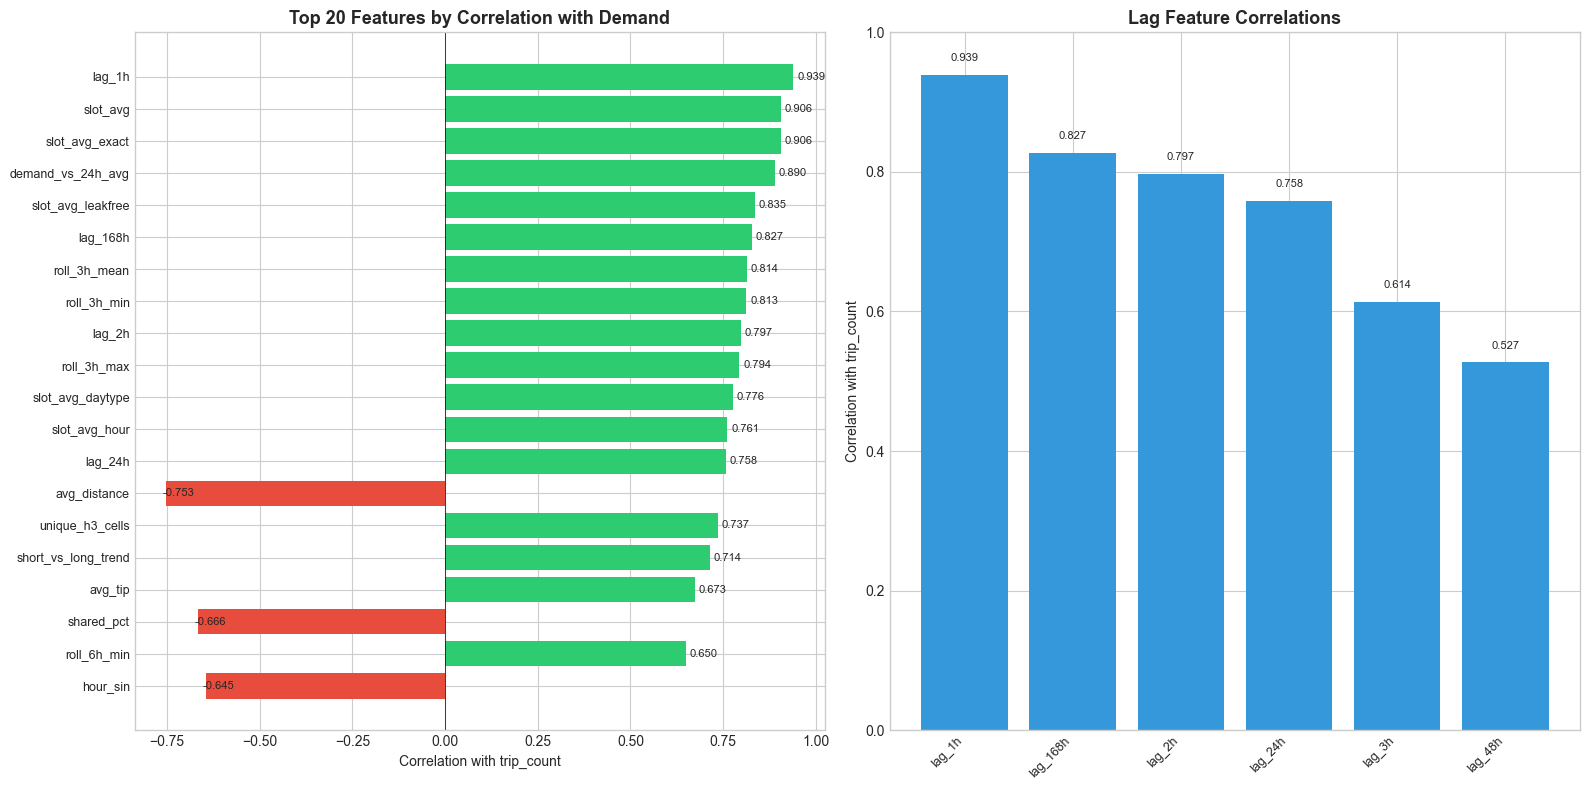

In [ ]:
numeric_cols = citywide_hourly.select_dtypes(include = [np.number]).columns
exclude = ['target_1h', 'target_2h', 'target_3h', 'weekend_hour']
feature_cols = [c for c in numeric_cols if c not in exclude and c != 'trip_count']

correlations = citywide_hourly[feature_cols + ['trip_count']].corr()['trip_count'].drop('trip_count')
correlations = correlations.dropna().sort_values(key = abs, ascending = False)

# Display top features
print("Top 25 features correlated with trip_count:")
print("-" * 50)
for i, (feat, corr) in enumerate(correlations.head(25).items(), 1):
    bar = "🟧" * int(abs(corr) * 30)
    direction = "+" if corr > 0 else "-"
    print(f"{i:2d}. {direction}{abs(corr):.3f}  {bar}  {feat}")

print()
print("Bottom 5 (least correlated):")
for feat, corr in correlations.tail(5).items():
    print(f"      {corr:+.3f}  {feat}")


fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 correlations
top20 = correlations.head(20)
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top20.values]
axes[0].barh(range(len(top20)), top20.values, color=colors)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20.index, fontsize=9)
axes[0].set_xlabel('Correlation with trip_count')
axes[0].set_title('Top 20 Features by Correlation with Demand', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].axvline(x=0, color='black', linewidth=0.5)
for i, v in enumerate(top20.values):
    axes[0].text(v + 0.01 * np.sign(v), i, f'{v:.3f}', va='center', fontsize=8)

# Lag features specifically
lag_features = [c for c in correlations.index if c.startswith('lag_')]
lag_corrs = correlations[lag_features].sort_values(ascending=False)
axes[1].bar(range(len(lag_corrs)), lag_corrs.values, color='#3498db')
axes[1].set_xticks(range(len(lag_corrs)))
axes[1].set_xticklabels(lag_corrs.index, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Correlation with trip_count')
axes[1].set_title('Lag Feature Correlations', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1)
for i, v in enumerate(lag_corrs.values):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=8)


plt.tight_layout()
plt.savefig('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/external/figures/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()


##### 11. Feature Importance
`Correlation check for non-linear patterns`

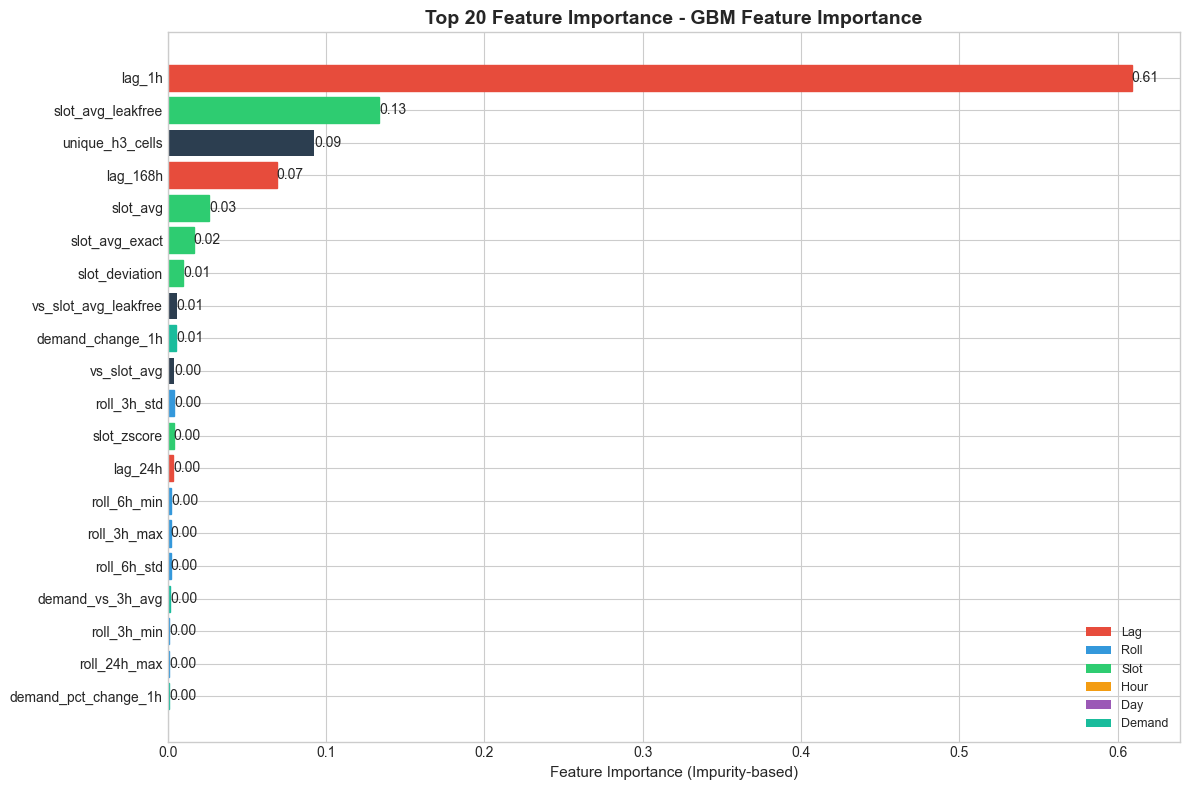

In [ ]:
model_cols = [c for c in feature_cols if citywide_hourly[c].dtype in ['int64', 'float64', 'bool']]
model_data = citywide_hourly[['hour_bucket', 'trip_count'] + model_cols].dropna().copy()

split_idx = int(len(model_data) * 0.8)
train = model_data.iloc[:split_idx]
test = model_data.iloc[split_idx:]

X_train = train[model_cols]
y_train = train['trip_count']
X_test = test[model_cols]
y_test = test['trip_count']

gbm = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gbm.fit(X_train, y_train)

y_pred = gbm.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
avg_demand = y_test.mean()

# Feature importance
importances = pd.Series(gbm.feature_importances_, index=model_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
top20_imp = importances.head(20)
bars = ax.barh(range(len(top20_imp)), top20_imp.values, color = '#2c3e50')
ax.set_yticks(range(len(top20_imp)))
ax.set_yticklabels(top20_imp.index, fontsize=10)
ax.set_xlabel('Feature Importance (Impurity-based)', fontsize=11)
ax.set_title('Top 20 Feature Importance - GBM Feature Importance', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for i, (feat, imp) in enumerate(top20_imp.items()):
    ax.text(imp, i, f'{imp:.2f}', va='center', ha='left', fontsize=10)

category_colors = {
    'lag': '#e74c3c',
    'roll': '#3498db',
    'slot': '#2ecc71',
    'hour': '#f39c12',
    'day': '#9b59b6',
    'demand': '#1abc9c'
}
for i, feat in enumerate(top20_imp.index):
    for prefix, color in category_colors.items():
        if feat.startswith(prefix):
            bars[i].set_color(color)
            break


legend_elements = [Patch(facecolor=c, label=k.title()) 
                   for k, c in category_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/external/figures/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
citywide_hourly.to_parquet('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed/chirde.citywide_hourly.parquet', index=False)
h3_hourly_comp.to_parquet('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed/chirde.h3_hourly_comp.parquet', index=False)
cta_stations.to_parquet('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed/chirde.cta_stations.parquet', index=False)

In [ ]:
feature_registry = {
    'target_primary': 'trip_count',
    'target_next_hour': 'target_1h',
    'target_surge': 'is_surge',
    'target_reposition': 'reposition_signal',

    'features_calendar': [
        'hour', 'day_of_week', 'day_of_month', 'week_of_year',
        'is_weekend', 'is_holiday', 'is_nye_evening',
        'holiday_proximity', 'is_holiday_week'
    ],
    'features_cyclical': [
        'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'dom_sin', 'dom_cos'
    ],
    'features_lag': [c for c in citywide_hourly.columns if c.startswith('lag_')],
    'features_rolling': [c for c in citywide_hourly.columns if c.startswith('roll_')],
    'features_demand_ratio': [
        'demand_change_1h', 'demand_change_24h', 'demand_pct_change_1h',
        'demand_vs_3h_avg', 'demand_vs_24h_avg', 'short_vs_long_trend'
    ],
    'features_interaction': [
        'is_party_time', 'is_work_commute', 'is_late_night', 'is_business_day'
    ],
    'features_slot': [
        'slot_avg', 'slot_std', 'vs_slot_avg', 'slot_zscore',
        'slot_deviation', 'slot_avg_leakfree', 'vs_slot_avg_leakfree',
        'slot_avg_exact', 'slot_avg_daytype', 'slot_avg_hour'
    ],
    'features_auxiliary': [
        'avg_fare', 'avg_duration_sec', 'avg_distance',
        'shared_pct', 'avg_tip', 'unique_areas', 'unique_h3_cells'
    ],
    'features_spatial_h3': [
        'cell_avg_fare', 'cell_avg_duration_min', 'cell_avg_distance',
        'cell_tip_rate', 'cell_latitude', 'cell_longitude',
        'demand_percentile', 'cell_total_trips_norm',
        'neighbor_avg_demand', 'demand_vs_neighbors'
    ],
    'categorical_features': [
        'period_of_day', 'day_type', 'daytype_period',
        'holiday_name', 'day_name', 'demand_category'
    ],
}

if get_weather:
    feature_registry['features_weather'] = [
        'temperature_f', 'feels_like_f', 'humidity', 'precipitation_mm',
        'snowfall_cm', 'wind_speed_kmh', 'weather_code',
        'is_raining', 'is_snowing', 'weather_misery'
    ]

if get_stations:
    feature_registry['features_cta'] = [
        'has_cta_station', 'cta_lines_at_cell'
    ]

if get_ridership:
    feature_registry['features_cta_ridership'] = [
        'cta_total_rides', 'cta_avg_ratio', 'cta_stations_low'
    ]

all_city = []
all_h3 = []
for key, val in feature_registry.items():
    if key.startswith('features_') and isinstance(val, list):
        all_city.extend([f for f in val if f in citywide_hourly.columns])
        all_h3.extend([f for f in val if f in h3_hourly_comp.columns])

feature_registry['all_numeric_citywide'] = list(set(all_city))
feature_registry['all_numeric_h3'] = list(set(all_h3))

with open('/Volumes/T7/DS Projects/Chicago Ride Demand Forecasting/data/processed/feature_registry.json', 'w') as f:
    json.dump(feature_registry, f, indent=2)